In [4]:
!pip install scikit-learn
!pip install matplotlib
!pip install seaborn

📂 Step 1: Loading Data from Data.csv...
✅ Loaded: 2200 rows, 13 columns

🔍 Step 2: Initial Inspection...
<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   N                    2200 non-null   int64  
 1   P                    2200 non-null   int64  
 2   K                    2200 non-null   int64  
 3   temperature          2200 non-null   float64
 4   humidity             2200 non-null   float64
 5   ph                   2200 non-null   float64
 6   rainfall             2200 non-null   float64
 7   label                2200 non-null   str    
 8   fertilizer           2200 non-null   str    
 9   N_status             2200 non-null   str    
 10  P_status             2200 non-null   str    
 11  K_status             2200 non-null   str    
 12  recommendation_note  2200 non-null   str    
dtypes: float64(4), int64(3), str(6)
memory usage

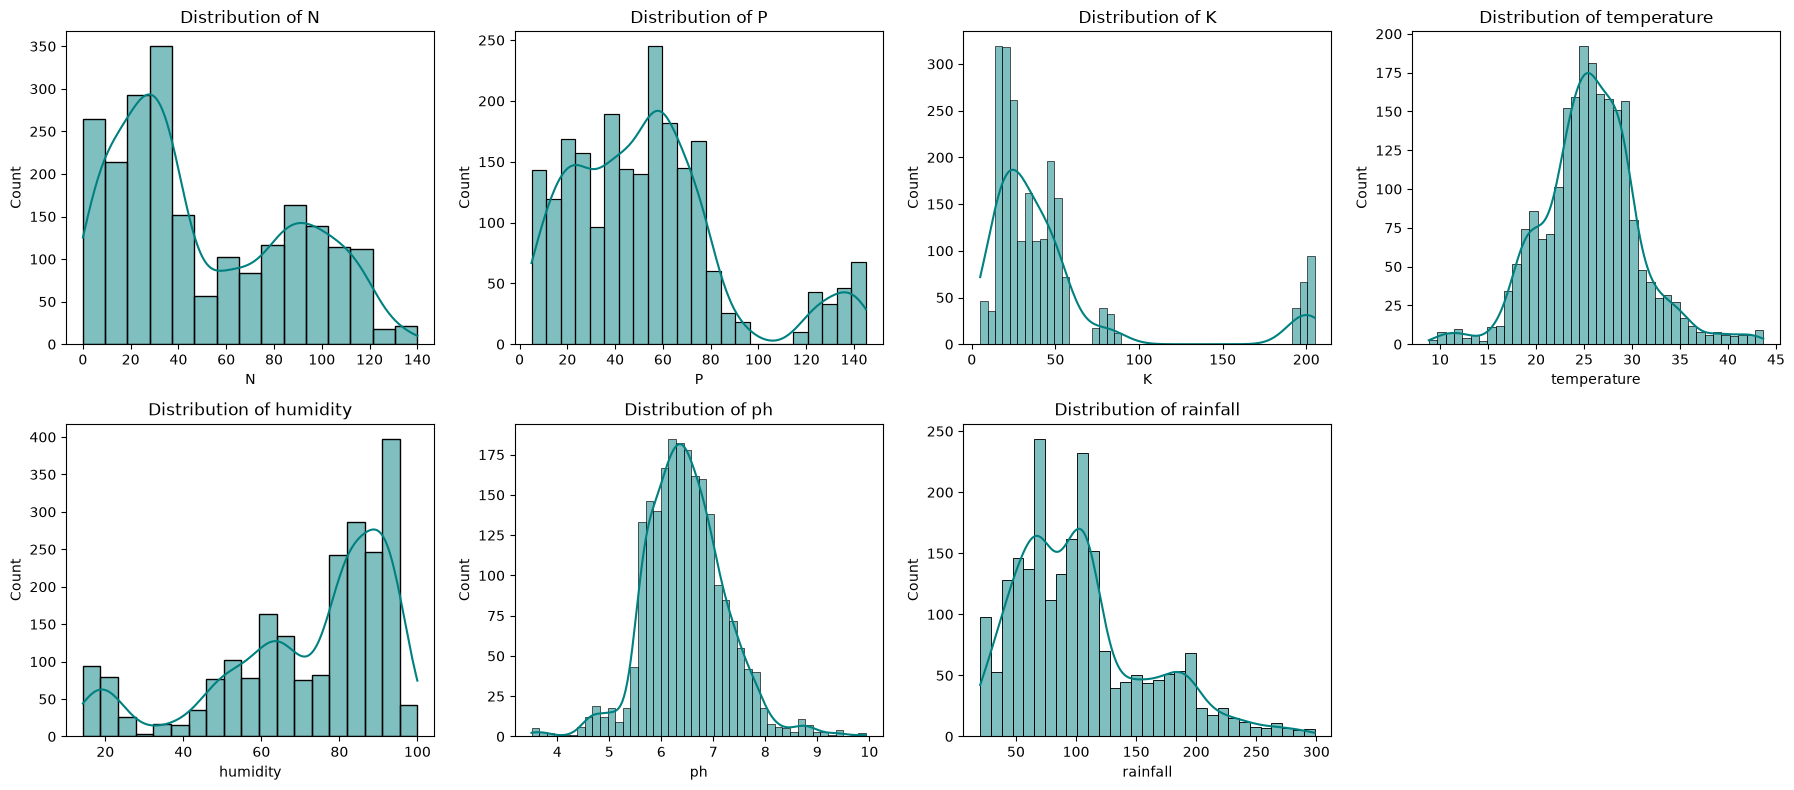


🔗 Step 6: Bivariate Analysis...


/tmp/ipykernel_29633/3142203209.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='label', data=df, ax=axes[0], order=df['label'].value_counts().index, palette='viridis')
/tmp/ipykernel_29633/3142203209.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='fertilizer', data=df, ax=axes[1], order=df['fertilizer'].value_counts().index, palette='Set2')


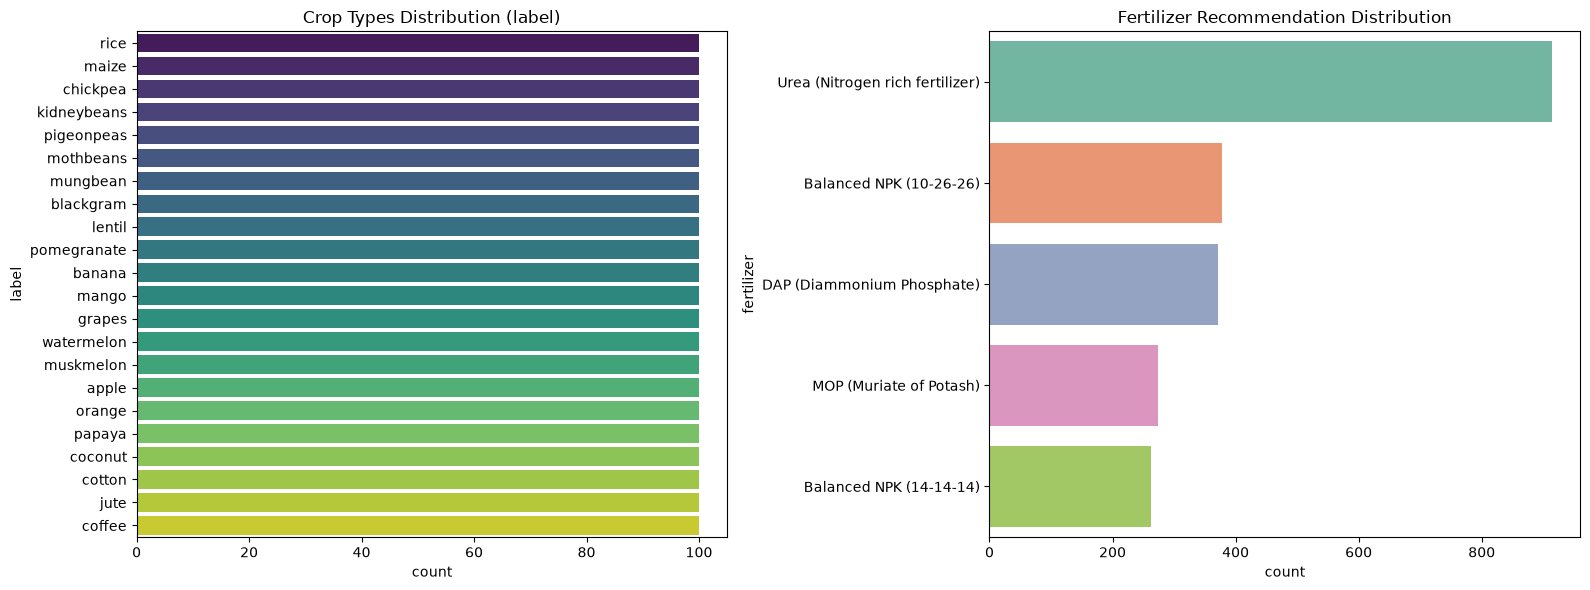


📈 Step 7: Correlation Analysis...


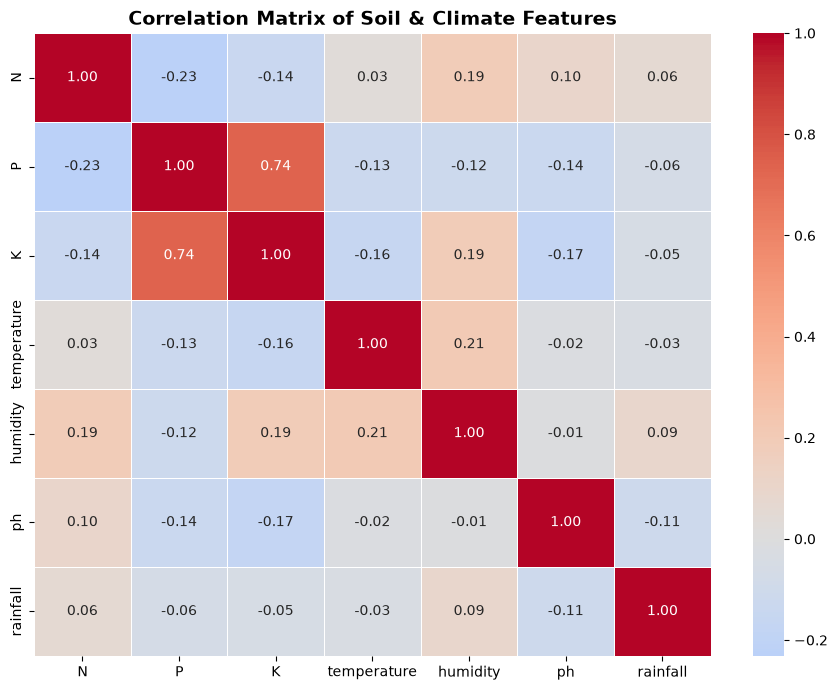


💾 Step 8: Saving Cleaned Data...
✅ EDA Complete! บันทึกไฟล์ 'Data_cleaned_EDA.csv' เรียบร้อย
ข้อมูลพร้อมใช้งาน: 2200 แถว, 12 คอลัมน์


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# CROP & FERTILIZER EDA WORKFLOW — วิเคราะห์ข้อมูล Data.csv
# ============================================================

# Step 1: Load Data
print("📂 Step 1: Loading Data from Data.csv...")
df = pd.read_csv('Data.csv')
print(f"✅ Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

# Step 2: Initial Inspection
print("\n🔍 Step 2: Initial Inspection...")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())

# Step 3: Check Missing Values & Duplicates
print("\n⚠️ Step 3: Checking Missing Values & Duplicates...")
missing = df.isnull().sum()
print(f"จำนวน Missing Values ทั้งหมด: {missing.sum()} จุด")

num_duplicates = df.duplicated().sum()
print(f"พบข้อมูลซ้ำซ้อน (Duplicates): {num_duplicates} แถว")

# Step 4: Data Cleaning & Drop Redundant Columns
print("\n🔧 Step 4: Data Cleaning...")
if num_duplicates > 0:
    df = df.drop_duplicates()
    print(f"✅ ลบแถวซ้ำออกเรียบร้อย คงเหลือ {len(df)} แถว")

# ตัดคอลัมน์ที่เป็นค่าคงที่ซ้ำกันทุกแถวออก (ไม่มีประโยชน์ต่อการสร้างโมเดล)
if 'recommendation_note' in df.columns:
    df = df.drop(columns=['recommendation_note'])
    print("✅ ลบคอลัมน์ 'recommendation_note' ออกเรียบร้อย")

# Step 5: Univariate Analysis (การกระจายตัวของปัจจัยตัวเลขทั้ง 7 ปัจจัย)
print("\n📊 Step 5: Univariate Analysis...")
numeric_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
existing_num_cols = [c for c in numeric_cols if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(existing_num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribution of {col}')

# ปิดช่องกราฟที่เกินมา
if len(existing_num_cols) < len(axes):
    for j in range(len(existing_num_cols), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Step 6: Bivariate Analysis (วิเคราะห์สัดส่วนชนิดพืชและประเภทปุ๋ย)
print("\n🔗 Step 6: Bivariate Analysis...")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

if 'label' in df.columns:
    sns.countplot(y='label', data=df, ax=axes[0], order=df['label'].value_counts().index, palette='viridis')
    axes[0].set_title('Crop Types Distribution (label)')

if 'fertilizer' in df.columns:
    sns.countplot(y='fertilizer', data=df, ax=axes[1], order=df['fertilizer'].value_counts().index, palette='Set2')
    axes[1].set_title('Fertilizer Recommendation Distribution')

plt.tight_layout()
plt.show()

# Step 7: Correlation Analysis (เมทริกซ์ความสัมพันธ์)
print("\n📈 Step 7: Correlation Analysis...")
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(9, 7))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Soil & Climate Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Step 8: Save Cleaned Data
print("\n💾 Step 8: Saving Cleaned Data...")
df.to_csv('Data_cleaned_EDA.csv', index=False)
print("=" * 60)
print("✅ EDA Complete! บันทึกไฟล์ 'Data_cleaned_EDA.csv' เรียบร้อย")
print(f"ข้อมูลพร้อมใช้งาน: {df.shape[0]} แถว, {df.shape[1]} คอลัมน์")
print("=" * 60)

In [6]:
import pandas as pd

# โหลดข้อมูล
df = pd.read_csv('Data.csv')

# ตัดออก 5 คอลัมน์ที่ไม่จำเป็นสำหรับ Task 1 (ตัด fertilizer ออก)
drop_task1 = ['fertilizer', 'N_status', 'P_status', 'K_status', 'recommendation_note']
df_task1 = df.drop(columns=[c for c in drop_task1 if c in df.columns])

# บันทึกไฟล์ CSV สำหรับ Task 1
df_task1.to_csv('Plant.csv', index=False)

print("✅ [Task 1] สร้างไฟล์ 'Plant.csv' สำเร็จ!")
print(f"ขนาดข้อมูล: {df_task1.shape[0]} แถว, {df_task1.shape[1]} คอลัมน์")
print(f"คอลัมน์ทั้งหมด: {df_task1.columns.tolist()}")

✅ [Task 1] สร้างไฟล์ 'Plant.csv' สำเร็จ!
ขนาดข้อมูล: 2200 แถว, 8 คอลัมน์
คอลัมน์ทั้งหมด: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']


In [7]:
import pandas as pd

# โหลดข้อมูล
df = pd.read_csv('Data.csv')

# ตัดออก 4 คอลัมน์ส่วนเกินสำหรับ Task 2 (เก็บ label ไว้ใช้เป็น Feature)
drop_task2 = ['N_status', 'P_status', 'K_status', 'recommendation_note']
df_task2 = df.drop(columns=[c for c in drop_task2 if c in df.columns])

# บันทึกไฟล์ CSV สำหรับ Task 2
df_task2.to_csv('Fertilizer.csv', index=False)

print("✅ [Task 2] สร้างไฟล์ 'Fertilizer.csv' สำเร็จ!")
print(f"ขนาดข้อมูล: {df_task2.shape[0]} แถว, {df_task2.shape[1]} คอลัมน์")
print(f"คอลัมน์ทั้งหมด: {df_task2.columns.tolist()}")

✅ [Task 2] สร้างไฟล์ 'Fertilizer.csv' สำเร็จ!
ขนาดข้อมูล: 2200 แถว, 9 คอลัมน์
คอลัมน์ทั้งหมด: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label', 'fertilizer']
